In [1]:
import time
import numpy as np
import qcodes as qc
from qcodes import Station
from qcodes.utils.dataset.doNd import do1d, do2d
from qcodes.dataset.plotting import plot_dataset
from macros import *

# instrument setup - station

In [2]:
station = qc.Station(config_file = 'SET_Station_config.yaml', use_monitor='True')

In [3]:
from zhinst.qcodes import ZISession
mfli_addr = "192.168.0.220"
DEVICE_ID = "dev30577"
session = ZISession(mfli_addr)
device = session.connect_device(DEVICE_ID)
station.add_component(device,name='lockin')

'lockin'

In [4]:
lockin = station.lockin
dac = station.load_instrument('qdac')

Connected to: QDevil QDAC-II (serial:200, firmware:11-1.21) in 0.17s


# data handler - database file

In [5]:
qc.config.core.db_location = "./data/20250902_TFT50nm.db"
qc.initialise_or_create_database_at(qc.config.core.db_location)

In [6]:
exp = qc.load_or_create_experiment(experiment_name="sd_experiment",
                                sample_name = "TFT50nm_W=5nm_L=2nm")

# set up experiment parameters 

In [7]:
from qcodes.instrument.parameter import ManualParameter

count = ManualParameter(name='count', label='Index', unit='', initial_value=-1)

def get_lockin_x():
    return lockin.demods[0].sample()['x']

def get_lockin_theta():
    return np.arctan2(lockin.demods[0].sample()['y'], lockin.demods[0].sample()['x'])*180/np.pi

def get_current():
    return np.sqrt(lockin.demods[0].sample()['x']**2+lockin.demods[0].sample()['y']**2)

def get_lockin_V():
    return lockin.sigouts[0].amplitudes[1].value()

def get_resistance():
    return lockin.sigouts[0].amplitudes[1].value()/np.sqrt(lockin.demods[0].sample()['x']**2+lockin.demods[0].sample()['y']**2)

      
lockin_x = qc.Parameter(name='X',label='Voltage',unit='V',get_cmd=get_lockin_x)
lockin_theta = qc.Parameter(name='Theta',label='Theta',unit='deg',get_cmd=get_lockin_theta)
lockin_current = qc.Parameter(name='I',label='Current',unit='A',get_cmd=get_current,scale = 1e5)
device_resistance = qc.Parameter(name='r',label='resistance',unit='$/ohm$',get_cmd=get_resistance,scale = 1e-5)

In [8]:
dac.reset()

In [9]:
basic_mfli_setup(lockin, V_exc=0, Voffset=0, frequency=1000)
dac.ch02.dc_constant_V(0)

In [10]:
dac.ch02.output_mode(range='low', filter='dc')


In [11]:
dac.ch02.print_readable_snapshot()

qdac_ch02:
	parameter                    value
--------------------------------------------------------------------------------
current_last_A                :	0 (A)
current_start_on              :	None 
dc_constant_V                 :	0 (V)
dc_last_V                     :	0 (V)
dc_mode                       :	FIX 
dc_next_V                     :	0 (V)
dc_slew_rate_V_per_s          :	inf (V/s)
fetch_current_A               :	[] (A)
measurement_aperture_s        :	0.016667 (s)
measurement_count             :	1 
measurement_delay_s           :	0 (s)
measurement_nplc              :	1 
measurement_range             :	HIGH 
measurement_start_on_external :	None 
n_masurements_remaining       :	0 
n_measurements_available      :	0 
output_filter                 :	dc (Hz)
output_high_range_maximum_V   :	10.012 (V)
output_high_range_minimum_V   :	-10.012 (V)
output_low_range_maximum_V    :	2.0025 (V)
output_low_range_minimum_V    :	-2.0025 (V)
output_range                  :	low 
read_current_A

# measure lockin, sweep lockin

Starting experimental run with id: 26. Using 'qcodes.dataset.do1d'


  0%|          | 0/20 [00:00<?, ?it/s]

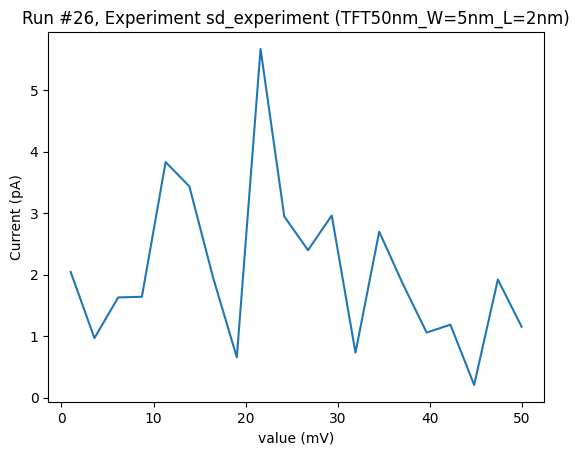

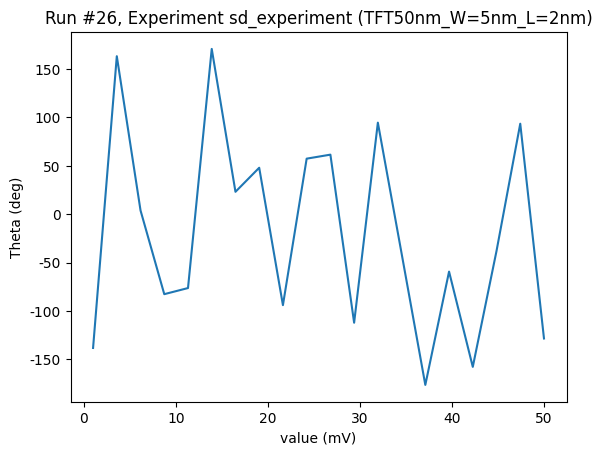

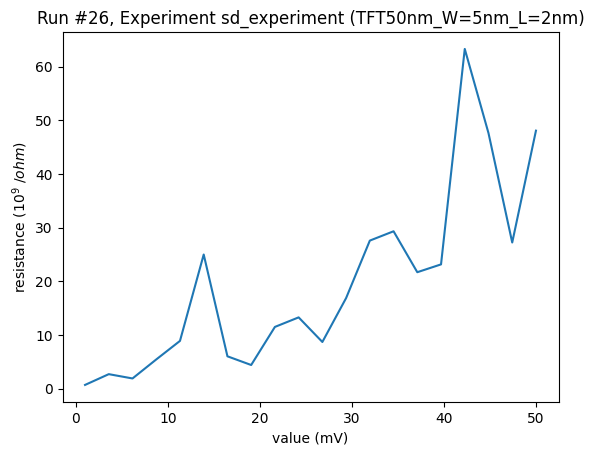

In [12]:
# lockin setting
lockin_dc = 0
lockin_ac = 0.001
basic_mfli_setup(lockin, V_exc=lockin_ac, Voffset=lockin_dc, frequency=1000)

# experiment setting
Vg = 0
dac.ch02.output_mode(range='low', filter='dc')
dac.ch02.dc_constant_V(Vg)

volt_start= 0.001
volt_stop = 0.05
interval_time = 0.3
steps = 20
do1d(
    lockin.sigouts[0].amplitudes[1].value, 
    volt_start, volt_stop, steps, interval_time,
    lockin_current, lockin_theta,device_resistance,
    measurement_name=f'Vg={Vg}',
    do_plot=True,
    show_progress=True)
dac.ch02.dc_constant_V(0)
basic_mfli_setup(lockin, V_exc=lockin_ac, Voffset=lockin_dc, frequency=1000)
dac.reset()

In [9]:
v_dc = 0.5
V_ac = 0.02
interval_time = 0.03 # 3 times the time constant
basic_mfli_setup(lockin, V_exc=V_ac, Voffset=v_dc, frequency=1e3)

do1d(count, 
    0, 1000, 1000, interval_time,
    lockin_x, lockin_theta,
    measurement_name=f'Voffset={v_dc} V_exc={V_ac}',)

Starting experimental run with id: 14. Using 'qcodes.dataset.do1d'


(Voffset=0.5 V_exc=0.02 #14@/Users/4hsiang/Desktop/Jack/python_project/SET/data/20250725_lockin_dc_ac.db
 -------------------------------------------------------------------------------------------------------
 count - numeric
 X - numeric
 Theta - numeric,
 (None,),
 (None,))

Starting experimental run with id: 16. Using 'qcodes.dataset.do2d'


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

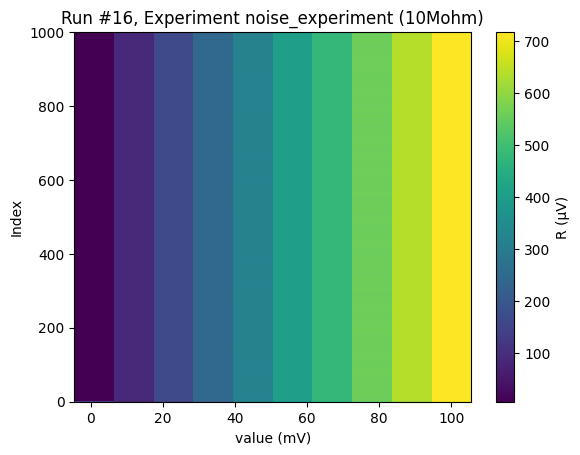

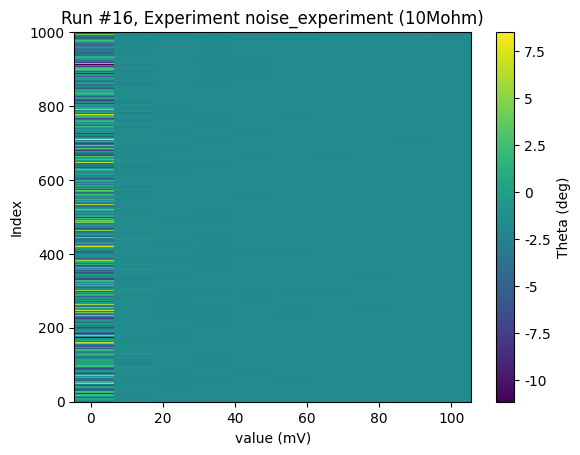

In [16]:
ds, axes,cbs = do2d(
    lockin.sigouts[0].amplitudes[1].value, 0.001, 0.1, 10,interval_time,
    count, 0, 1000, 1000, interval_time,
    lockin_x, lockin_theta,
    measurement_name=f'noise_sweep',
    do_plot=True,
    show_progress=True,
    )

# measure lockin, sweep qdac

Starting experimental run with id: 24. Using 'qcodes.dataset.do1d'


  0%|          | 0/50 [00:00<?, ?it/s]

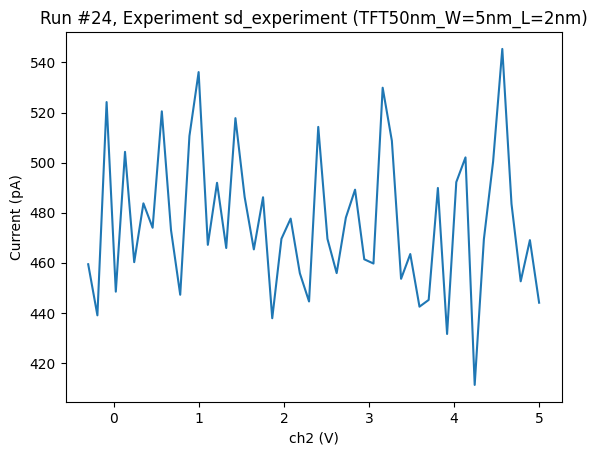

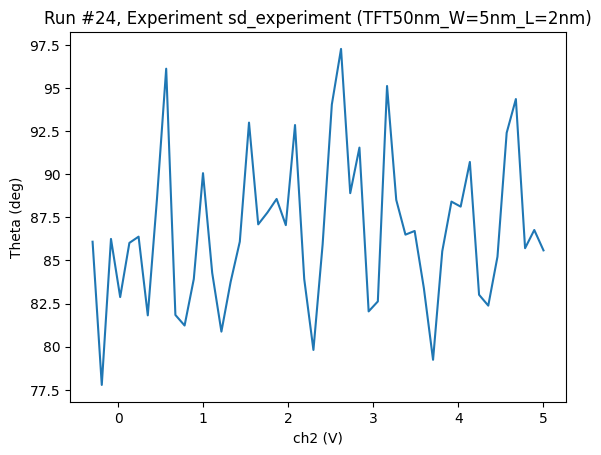

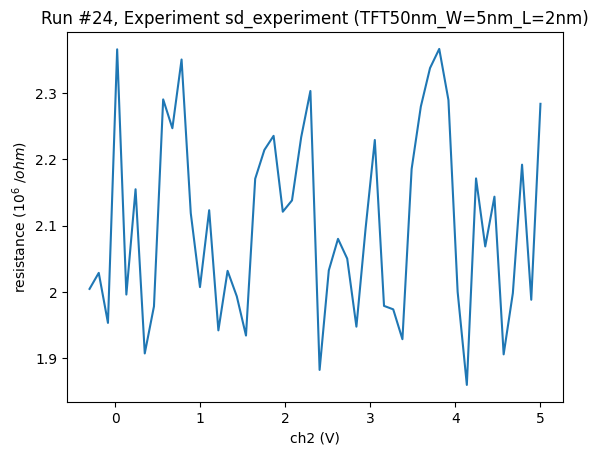

In [54]:
# lockin setting
lockin_dc = 0
lockin_ac = 0.001
basic_mfli_setup(lockin, V_exc=lockin_ac, Voffset=lockin_dc, frequency=1000)

# experiment setting
volt_start= -0.3
volt_stop = 5
interval_time = 0.3
steps = 50
do1d(
    dac.ch02.dc_constant_V, 
    volt_start, volt_stop, steps, interval_time,
    lockin_current, lockin_theta,device_resistance,
    measurement_name=f'gate -0.3 to 5',
    do_plot=True,
    show_progress=True)
dac.ch02.dc_constant_V(0)
dac.reset()

In [34]:
dac.ch02.dc_constant_V(0)

Starting experimental run with id: 25. Using 'qcodes.dataset.do2d'


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

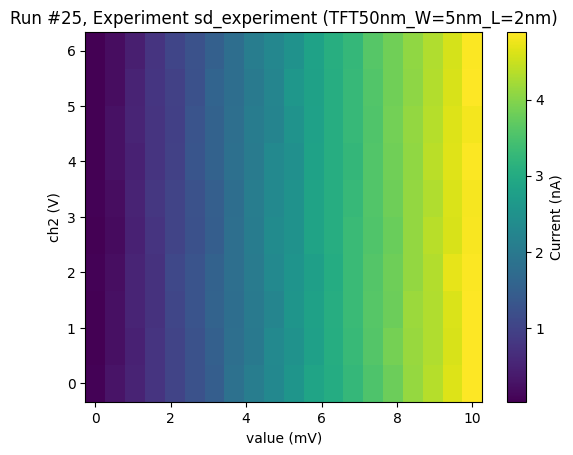

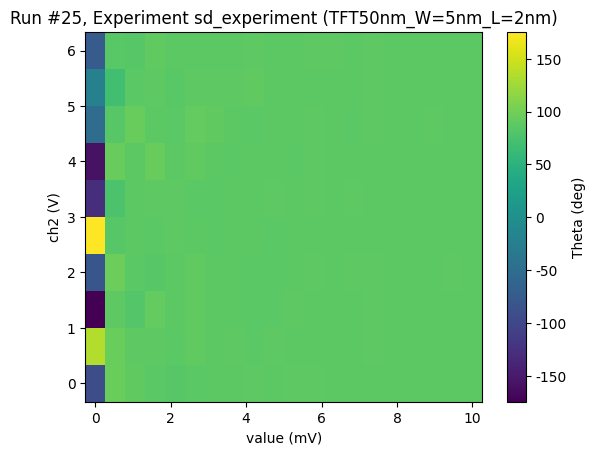

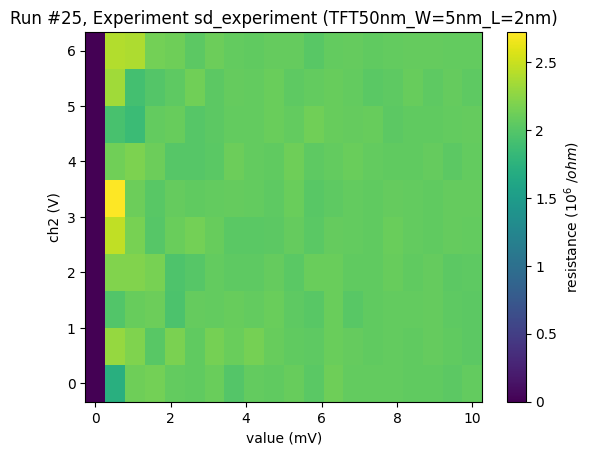

In [55]:

lockin_v_start = 0
lockin_v_stop = 0.01
lockin_v_steps = 20

dag_v_start = 0
dag_v_stop = 6
dag_v_steps = 10
ds, axes,cbs = do2d(
    lockin.sigouts[0].amplitudes[1].value, lockin_v_start,lockin_v_stop, lockin_v_steps, interval_time,
    dac.ch02.dc_constant_V,dag_v_start, dag_v_stop, dag_v_steps, interval_time,
    lockin_current, lockin_theta,device_resistance,
    measurement_name=f'gate vs sd',
    do_plot=True,
    show_progress=True,
    )